In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
# Cargar GeoDataFrame de microplásticos
mp_gdf = gpd.read_file(
    "../data/GeoDataFrame/gdf_microplastics.gpkg",
    crs="EPSG:4326"
)

# Cargar GeoDataFrame de perfiles ecológicos oceanográficos
grid_gdf = gpd.read_file("../data/grid_ocean/grilla_agua_perfiles.gpkg", crs="EPSG:4326")

/usr/local/python/3.12.1/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: driver GPKG does not support open option CRS
  return ogr_read(
/usr/local/python/3.12.1/lib/python3.12/site-packages/pyogrio/raw.py:200: RuntimeWarning: driver GPKG does not support open option CRS
  return ogr_read(


In [3]:
# Creamos un ID único para cada punto de microplástico
mp_gdf = mp_gdf.reset_index(drop=True)
mp_gdf["mp_id"] = mp_gdf.index

# Realizar la unión espacial más cercana
mp_with_env = gpd.sjoin_nearest(
    mp_gdf,
    grid_gdf.drop(columns=['lat','lon']),  # opcional, mantener solo variables + geometry
    how='left',
    distance_col='dist_deg'
)

# Eliminar duplicados manteniendo el más cercano
mp_with_env = (
    mp_with_env
    .sort_values("dist_deg", ascending=False)
    .drop_duplicates(subset=['mp_id'])
)
mp_with_env = (
    mp_with_env
    .sort_values("mp_id")
)
mp_with_env.head()

/usr/local/python/3.12.1/lib/python3.12/site-packages/geopandas/array.py:407: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


,microplastics_measurement,unit,concentration_class_range,mesh_size_mm,lat,lon,geometry,mp_id,index_right,distance_to_coast_km,temperature,salinity,chlorophyll,nitrate,phosphate,oxygen_dissolved,oxygen_utilization,cluster_num,profile_eco,dist_deg
0,0.000000,pieces/m3,0-0.0005,0.335,45.28,-60.29,POINT (-60.29 45.28),0,117453,60.127269,6.299999,32.785152,0.509678,5.787156,0.834564,265.093384,57.033932,1,cold_shelf,0.350000
1,0.002276,pieces/m3,0.0005-0.005,0.335,40.93,-70.65,POINT (-70.65 40.93),1,114724,39.954054,12.127690,34.283134,0.336776,5.251710,0.567093,248.744659,25.638559,1,cold_shelf,0.165529
2,0.004320,pieces/m3,0.0005-0.005,0.335,40.93,-70.65,POINT (-70.65 40.93),2,114724,39.954054,12.127690,34.283134,0.336776,5.251710,0.567093,248.744659,25.638559,1,cold_shelf,0.165529
3,0.000000,pieces/m3,0-0.0005,0.335,40.30,-69.77,POINT (-69.77 40.3),3,114370,82.057580,12.127690,34.283134,0.494065,5.251710,0.567093,248.744659,25.638559,1,cold_shelf,0.304795
4,0.000000,pieces/m3,0-0.0005,0.335,39.88,-67.15,POINT (-67.15 39.88),4,114012,357.363239,8.405213,35.200493,0.848809,14.126949,0.930865,236.792160,56.462185,0,open_sea_temperate,0.192094


In [5]:
mp_with_env["profile_eco"].value_counts()


profile_eco
warm_coastal          8734
open_sea_temperate    5557
subpolar_open_sea     2666
cold_shelf            2296
cold_open_sea           69
Name: count, dtype: int64

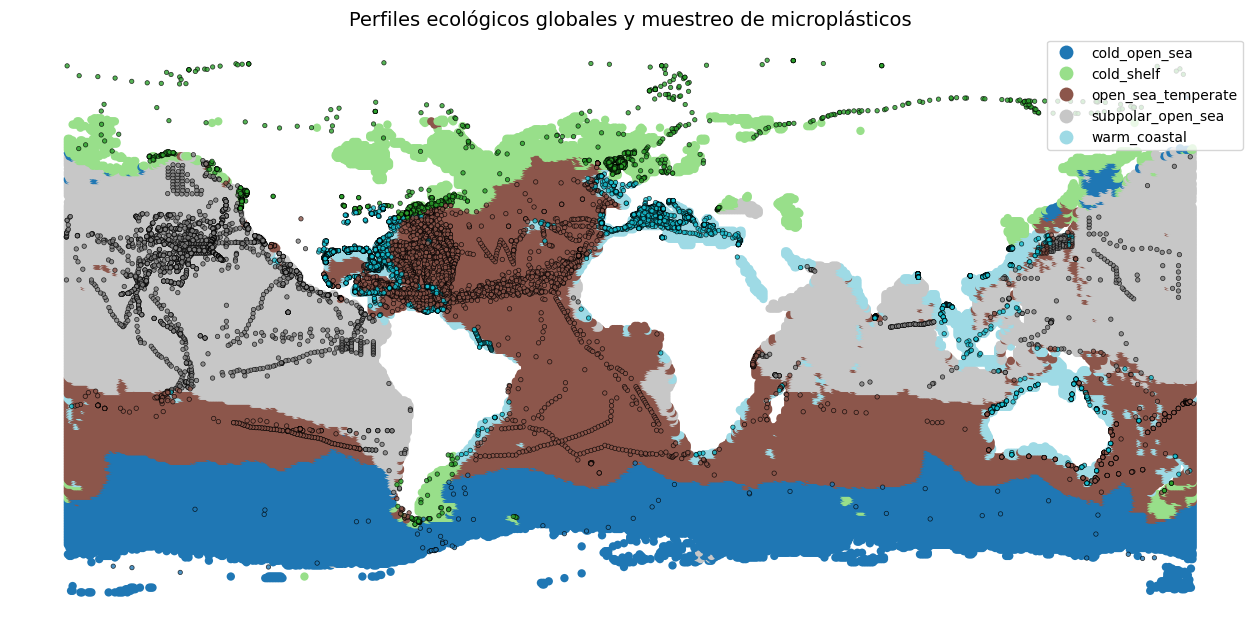

In [6]:
# Visualización de los perfiles ecológicos y puntos de microplásticos

fig, ax = plt.subplots(1, 1, figsize=(16, 9))

# 1️⃣ Grilla (perfiles ecológicos)
grid_gdf.plot(
    column='profile_eco',
    categorical=True,
    cmap='tab20',
    legend=True,
    linewidth=0,
    ax=ax
)

# 2️⃣ Puntos de microplásticos
mp_with_env.plot(
    ax=ax,
    column = 'profile_eco',
    categorical=True,
    markersize=10,
    alpha=0.8,
    edgecolor='black',
    linewidth=0.5,
    label='Microplastic samples'
)

ax.set_title("Perfiles ecológicos globales y muestreo de microplásticos", fontsize=14)
ax.set_axis_off()

plt.show()

In [7]:
cols_keep = [
    'mp_id', 'lat', 'lon', 'geometry',
    'microplastics_measurement', 'unit', 'concentration_class_range',
    'mesh_size_mm',
    'distance_to_coast_km',
    'temperature', 'salinity', 'chlorophyll', 'nitrate', 'phosphate',
    'oxygen_dissolved', 'oxygen_utilization',
    'profile_eco', 'dist_deg'
]
mp_with_env = mp_with_env.dropna(subset=['microplastics_measurement', 'mesh_size_mm'])
mp_clean = mp_with_env[cols_keep]
mp_clean.to_file(
    "../data/grid_ocean/gdf_microplastics_with_env.gpkg",
    driver="GPKG"
)
mp_clean

,mp_id,lat,lon,geometry,microplastics_measurement,unit,concentration_class_range,mesh_size_mm,distance_to_coast_km,temperature,salinity,chlorophyll,nitrate,phosphate,oxygen_dissolved,oxygen_utilization,profile_eco,dist_deg
0,0,45.280000,-60.290000,POINT (-60.29 45.28),0.000000,pieces/m3,0-0.0005,0.3350,60.127269,6.299999,32.785152,0.509678,5.787156,0.834564,265.093384,57.033932,cold_shelf,0.350000
1,1,40.930000,-70.650000,POINT (-70.65 40.93),0.002276,pieces/m3,0.0005-0.005,0.3350,39.954054,12.127690,34.283134,0.336776,5.251710,0.567093,248.744659,25.638559,cold_shelf,0.165529
2,2,40.930000,-70.650000,POINT (-70.65 40.93),0.004320,pieces/m3,0.0005-0.005,0.3350,39.954054,12.127690,34.283134,0.336776,5.251710,0.567093,248.744659,25.638559,cold_shelf,0.165529
3,3,40.300000,-69.770000,POINT (-69.77 40.3),0.000000,pieces/m3,0-0.0005,0.3350,82.057580,12.127690,34.283134,0.494065,5.251710,0.567093,248.744659,25.638559,cold_shelf,0.304795
4,4,39.880000,-67.150000,POINT (-67.15 39.88),0.000000,pieces/m3,0-0.0005,0.3350,357.363239,8.405213,35.200493,0.848809,14.126949,0.930865,236.792160,56.462185,open_sea_temperate,0.192094
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19317,19317,-5.933333,39.360000,POINT (39.36 -5.93333),188.300000,pieces kg-1 d.w.,150-200,0.0007,102.177974,13.464818,34.985344,0.003898,21.074507,1.583272,147.353027,115.873299,open_sea_temperate,1.141948
19318,19318,-5.500000,39.120000,POINT (39.12 -5.5),155.270000,pieces kg-1 d.w.,150-200,0.0007,46.901614,17.833050,35.093750,0.142112,14.431973,1.130769,162.590759,78.066124,open_sea_temperate,1.332066
19319,19319,-6.450000,39.466667,POINT (39.46667 -6.45),58.070000,pieces kg-1 d.w.,20-150,0.0007,49.536977,16.662235,35.049408,-0.258756,16.213150,1.203066,166.246719,81.130661,open_sea_temperate,0.766123
19320,19320,-6.320000,39.210000,POINT (39.21 -6.32),210.000000,pieces kg-1 d.w.,>200,0.0007,49.536977,16.662235,35.049408,-0.258756,16.213150,1.203066,166.246719,81.130661,open_sea_temperate,1.042353


In [8]:
mp_clean.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
Index: 14155 entries, 0 to 19321
Data columns (total 18 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   mp_id                      14155 non-null  int64   
 1   lat                        14155 non-null  float64 
 2   lon                        14155 non-null  float64 
 3   geometry                   14155 non-null  geometry
 4   microplastics_measurement  14155 non-null  float64 
 5   unit                       14155 non-null  object  
 6   concentration_class_range  14155 non-null  object  
 7   mesh_size_mm               14155 non-null  float64 
 8   distance_to_coast_km       14155 non-null  float64 
 9   temperature                14155 non-null  float32 
 10  salinity                   14155 non-null  float32 
 11  chlorophyll                14155 non-null  float32 
 12  nitrate                    14155 non-null  float32 
 13  phosphate                  1

In [9]:
mp_clean.drop(columns='geometry').to_parquet("../data/grid_ocean/NOAA_encology.parquet", index=False)
print("✅ Dataset final listo para clustering")

✅ Dataset final listo para clustering
